In [66]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedKFold, cross_val_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score, precision_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder


In [67]:
df = pd.read_csv('../../data/ml_data/Feature_Engineered.csv', low_memory=False)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Remove anomalous data points (e.g., 2023 having only 7 rows)
df = df[df['renewal_year'] != 2023]
df = df.drop(columns=['renewal_year'], errors='ignore')


In [68]:
# Feature Encoding
cat_cols = [
    'proforma_account_stage', 'proforma_audit_status', 'current_world_pay_token',
    'proforma_membership_status', 'band', 'connection_group', 'tenure_group',
    'last_band', 'sentiment_category','cc_worst_sentiment','desire_to_cancel_agg','flag_risk_level','tenure_bucket'
]
cat_cols = [c for c in cat_cols if c in df.columns]

encoders = {}
for col in cat_cols:
    df[col] = df[col].astype(str).fillna('missing')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Quick imputation for any remaining missing values (required for some models like LogisticRegression)
df = df.fillna(0)


In [69]:
# Train-Test Split & Class Weights
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate weight for imbalanced classes
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()


In [70]:
#null check
for col in df.columns:
    null_count = df[col].isnull().sum()
    print(f"{col}: {null_count} null values")

proforma_account_stage: 0 null values
proforma_audit_status: 0 null values
current_world_pay_token: 0 null values
proforma_membership_status: 0 null values
tenure_years: 0 null values
band: 0 null values
amount: 0 null values
connection_group: 0 null values
tenure_group: 0 null values
#_of_connection: 0 null values
last_band: 0 null values
last_connections: 0 null values
price_change: 0 null values
churn: 0 null values
crm_contractor_sentiment_score_num: 0 null values
sentiment_category: 0 null values
total_calls: 0 null values
outbound_calls: 0 null values
inbound_calls: 0 null values
max_call_number: 0 null values
num_analysed_calls: 0 null values
serious_complaint_flag: 0 null values
other_complaint_flag: 0 null values
price_discussed_flag: 0 null values
discount_requested_flag: 0 null values
call_reschedule_flag: 0 null values
membership_alert_flag: 0 null values
competitor_mentioned_flag: 0 null values
switching_intent_flag: 0 null values
price_switching_flag: 0 null values
pct_pr

In [71]:
# Define Models to Compare
models = {
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, 
        scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss', n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, 
        scale_pos_weight=scale_weight, random_state=42, n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    )
}

In [72]:
# Train, Evaluate, and Compare
results = []
print("Training and evaluating models...\n")

for name, model in models.items():
    try:
        # Train the model
        model.fit(X_train, y_train)
        
        # Generate predictions
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        results.append({
            "Model": name,
            "ROC-AUC": roc_auc_score(y_test, proba),
            "PR-AUC": average_precision_score(y_test, proba),
            "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Overall Accuracy": accuracy_score(y_test, pred)
        })
        print(f"{name} complete.")
    except Exception as e:
        print(f"{name} failed: {e}")

Training and evaluating models...

XGBoost failed: [00:18:32] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:99: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`
[LightGBM] [Info] Number of positive: 6477, number of negative: 27031
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2753
[LightGBM] [Info] Number of data points in the train set: 33508, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193297 -> initscore=-1.428727
[LightGBM] [Info] Start training from score -1.428727
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [73]:
# Display the Final Comparison
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("MODEL COMPARISON (Ranked by ROC-AUC)")
display(results_df.round(4))

# Extract the best model based on ROC-AUC for further use
if not results_df.empty:
    best_model_name = results_df.iloc[0]['Model']
    best_model = models[best_model_name]
    print(f"\nBest Model Selected: {best_model_name}")

MODEL COMPARISON (Ranked by ROC-AUC)


,Model,ROC-AUC,PR-AUC,Balanced Accuracy,Recall,Precision,Overall Accuracy
0,LightGBM,0.9392,0.8355,0.8689,0.8487,0.6469,0.8812



Best Model Selected: LightGBM


In [74]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nProceeding with Best Model: {best_model_name} 🌟")

# Get probabilities for the best model
proba = best_model.predict_proba(X_test)[:, 1]

# Threshold Tuning
print('\nOptimized Evaluation (Threshold Tuning)')
thresholds = np.arange(0.1, 0.8, 0.02)
tune_results = []

for t in thresholds:
    pred_t = (proba >= t).astype(int)
    tune_results.append({
        'threshold': t,
        'balanced_acc': balanced_accuracy_score(y_test, pred_t),
        'recall': recall_score(y_test, pred_t),
        'precision': precision_score(y_test, pred_t, zero_division=0)
    })

tune_results_df = pd.DataFrame(tune_results)
best_row = tune_results_df.loc[tune_results_df['balanced_acc'].idxmax()]
best_threshold = best_row['threshold']

print(f"Best Threshold (by Balanced Acc): {best_threshold:.2f}")

pred_final = (proba >= best_threshold).astype(int)
print(classification_report(y_test, pred_final))


Proceeding with Best Model: LightGBM 🌟

Optimized Evaluation (Threshold Tuning)
Best Threshold (by Balanced Acc): 0.46
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      6759
           1       0.62      0.86      0.72      1619

    accuracy                           0.87      8378
   macro avg       0.79      0.87      0.82      8378
weighted avg       0.90      0.87      0.88      8378



In [75]:
# Cross-Validation
print('Cross-Validation (5-Fold)')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"CV Balanced Accuracy: {cv_scores.mean():.3f} (std: {cv_scores.std():.3f})")

Cross-Validation (5-Fold)
CV Balanced Accuracy: 0.864 (std: 0.004)


In [76]:
joblib.dump(best_model, '../../models/best_churn_model.pkl')
joblib.dump(encoders, '../../models/categorical_encoders.pkl')
joblib.dump(list(X_train.columns), '../../models/required_features.pkl')
joblib.dump(best_threshold, '../../models/optimal_threshold.pkl')

['../../models/optimal_threshold.pkl']

Heatmap

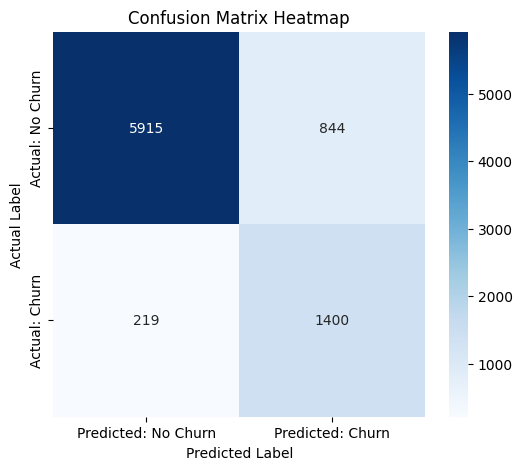

True Negatives  (TN): 5915
False Positives (FP): 844
False Negatives (FN): 219
True Positives  (TP): 1400


In [ ]:
cm = confusion_matrix(y_test, pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'])

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

In [78]:
comparison_df = pd.DataFrame({
    'Actual (y_true)': y_test.values,
    'Predicted (y_pred)': pred_final,
})

print("\nPREDICTION vs ACTUAL:")
display(comparison_df.head(20))


PREDICTION vs ACTUAL:


,Actual (y_true),Predicted (y_pred)
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
5,0,0
6,0,0
7,0,1
8,0,1
9,0,1


In [79]:
errors_df = comparison_df[comparison_df['Actual (y_true)'] != comparison_df['Predicted (y_pred)']]

print(f"\nTotal Misclassifications: {len(errors_df)}")
display(errors_df)


Total Misclassifications: 1063


,Actual (y_true),Predicted (y_pred)
7,0,1
8,0,1
9,0,1
21,0,1
44,1,0
...,...,...
8323,0,1
8350,0,1
8355,0,1
8356,0,1
